## BERTopic

Lo que hace BERTopic:

> Juntará todos los diálogos de personajes femeninos en un corpus

> Juntará todos los diálogos de personajes masculinos en otro corpus

> Descubrirá automáticamente los temas de cada corpus

> Compararemos qué temas dominan en cada género

In [ ]:
%%time

import pandas as pd
import re
import time
import torch
import contractions
import spacy
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from umap import UMAP
from hdbscan import HDBSCAN

# ---------- 0. Configurar dispositivo ----------

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

# ---------- 1. Cargar el dataset y excluir películas no-inglesas ----------

df = pd.read_pickle('Dataset_final_NLP.pkl')

# peliculas_excluidas = ['Talk to Her', 'Anatomy of a Fall']
# df = df[~df['Title'].isin(peliculas_excluidas)].reset_index(drop=True)

df_unique = df.drop_duplicates(subset='IMDb_ID').copy()

# ---------- 2. Colapsar palabras duplicadas consecutivas (ej. "good good" -> "good") ----------

def colapsar_repeticiones(texto):
    return re.sub(r'\b(\w+)( \1\b)+', r'\1', texto, flags=re.IGNORECASE)

# ---------- 3. Dividir en oraciones ----------

def split_sentences(texto):
    oraciones = re.split(r'(?<=[.!?])\s+', texto.strip())
    return [o.strip() for o in oraciones if len(o.strip()) > 0]

# ---------- 4. Construir el corpus, con filtros de personaje y frase ----------

MIN_PALABRAS_PERSONAJE = 15
MIN_PALABRAS_FRASE = 10

filas = []
personajes_excluidos_por_longitud = 0

for idx, row in df_unique.iterrows():
    script_dict = row['Script_Dict']
    genders_dict = row.get('Characters_Genders', {})

    for personaje, texto in script_dict.items():
        if not texto or not isinstance(texto, str) or texto.strip() == "":
            continue

        n_palabras = len(texto.split())
        if n_palabras <= MIN_PALABRAS_PERSONAJE:
            personajes_excluidos_por_longitud += 1
            continue

        genero = genders_dict.get(personaje, 'unknown')
        texto_limpio = contractions.fix(texto)
        texto_limpio = colapsar_repeticiones(texto_limpio)
        oraciones = split_sentences(texto_limpio)

        for oracion in oraciones:
            if len(oracion.split()) < MIN_PALABRAS_FRASE:
                continue
            filas.append({
                'Title': row['Title'],
                'Character': personaje,
                'Gender': genero,
                'Sentence': oracion
            })

df_sentences = pd.DataFrame(filas)

print(f"Personajes excluidos por tener <= {MIN_PALABRAS_PERSONAJE} palabras: {personajes_excluidos_por_longitud}")
print(f"Total de frases tras filtros: {len(df_sentences)}")

frases_male = df_sentences[df_sentences['Gender'] == 'male']['Sentence'].tolist()
frases_female = df_sentences[df_sentences['Gender'] == 'female']['Sentence'].tolist()

print(f"Frases masculinas: {len(frases_male)}")
print(f"Frases femeninas: {len(frases_female)}")

# ---------- 5. Stopwords ampliadas (muletillas + verbos de habla) ----------

muletillas_extra = {
    'yeah', 'yep', 'yup', 'nah', 'know', 'gonna', 'gotta', 'wanna',
    'hey', 'oh', 'ok', 'okay', 'alright', 'huh', 'uh', 'um', 'well',
    'like', 'just', 'really', 'actually', 'guess', 'mean', 'thing', 'things',
    'did', 'didn', 'don', 'll', 've', 'right', 'going', 'got', 'get'
}

verbos_habla = {
    'ask', 'asked', 'asking', 'asks',
    'tell', 'told', 'telling', 'tells',
    'say', 'said', 'saying', 'says',
    'question', 'questions', 'questioning',
    'talk', 'talked', 'talking', 'talks',
    'mention', 'mentioned', 'mentioning'
}

stopwords_completas = ENGLISH_STOP_WORDS.union(muletillas_extra).union(verbos_habla)

# ---------- 6. spaCy: lematización + filtro de nombres propios ----------

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
nlp.max_length = 3_000_000

def tokenizer_lematizado(texto):
    doc = nlp(texto)  # SIN .lower() aquí
    tokens = []
    for token in doc:
        if not token.is_alpha:
            continue
        if token.pos_ == "PROPN":
            continue
        lemma = token.lemma_.lower()  # el .lower() se mueve aquí
        if lemma in stopwords_completas:
            continue
        tokens.append(lemma)
    return tokens

vectorizer_model = CountVectorizer(
    tokenizer=tokenizer_lematizado,
    lowercase=False,   # <-- clave: evita que sklearn lowercase el texto antes de llegar a spaCy
    ngram_range=(1, 2)
)

# ---------- 7. Modelo de embeddings ----------

embedding_model = SentenceTransformer("all-mpnet-base-v2", device=device)

# ---------- 8. Función para entrenar BERTopic con HDBSCAN menos estricto (menos outliers) ----------

def entrenar_bertopic(frases, etiqueta):
    print(f"\n--- Entrenando BERTopic para: {etiqueta} ---")
    t0 = time.time()

    embeddings = embedding_model.encode(frases, show_progress_bar=True, batch_size=64)

    umap_model = UMAP(n_neighbors=15, n_components=5, low_memory=True, random_state=42)

    hdbscan_model = HDBSCAN(
        min_cluster_size=30, #Antes era 50
        min_samples=5,              # más bajo que min_cluster_size -> menos frases marcadas como outlier
        cluster_selection_epsilon=0.2,  # fusiona clusters muy cercanos entre sí # Antes era 0.3
        core_dist_n_jobs=1
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        min_topic_size=50,
        calculate_probabilities=False,
        verbose=False
    )

    topics, _ = topic_model.fit_transform(frases, embeddings=embeddings)

    n_outliers = sum(1 for t in topics if t == -1)
    print(f"Listo en {time.time()-t0:.1f} segundos | Outliers: {n_outliers}/{len(topics)} ({n_outliers/len(topics)*100:.1f}%)")

    return topic_model, topics

# ---------- 9. Entrenar un modelo para cada género ----------

modelo_male, topics_male = entrenar_bertopic(frases_male, "Masculino")
modelo_female, topics_female = entrenar_bertopic(frases_female, "Femenino")

# ---------- 10. Tabla legible ----------

def construir_tabla_temas(topic_model):
    info = topic_model.get_topic_info()
    filas_tabla = []
    for _, fila in info.iterrows():
        topic_id = fila['Topic']
        count = fila['Count']
        if topic_id == -1:
            palabras = "outliers (sin tema claro)"
        else:
            palabras_scores = topic_model.get_topic(topic_id)
            palabras = ", ".join([p for p, score in palabras_scores if p.strip() != "" and score > 0])
        filas_tabla.append({'Topic_ID': topic_id, 'Count': count, 'Palabras': palabras})
    return pd.DataFrame(filas_tabla)

tabla_male = construir_tabla_temas(modelo_male)
tabla_female = construir_tabla_temas(modelo_female)

print("\n=== TEMAS - DIÁLOGO MASCULINO ===")
print(tabla_male.to_string(index=False))

print("\n=== TEMAS - DIÁLOGO FEMENINO ===")
print(tabla_female.to_string(index=False))

# ---------- 11. Guardar ----------

# tabla_male.to_csv('temas_masculino.csv', index=False)
# tabla_female.to_csv('temas_femenino.csv', index=False)

Usando dispositivo: cuda
Personajes excluidos por tener <= 15 palabras: 724
Total de frases tras filtros: 18219
Frases masculinas: 13143
Frases femeninas: 4994


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8313.83it/s]



--- Entrenando BERTopic para: Masculino ---


Batches: 100%|██████████| 206/206 [00:13<00:00, 14.86it/s]


Listo en 55.1 segundos | Outliers: 7056/13143 (53.7%)

--- Entrenando BERTopic para: Femenino ---


Batches: 100%|██████████| 79/79 [00:05<00:00, 14.84it/s]


Listo en 26.1 segundos | Outliers: 2313/4994 (46.3%)

=== TEMAS - DIÁLOGO MASCULINO ===
 Topic_ID  Count                                                                                                                  Palabras
       -1   7056                                                                                                 outliers (sin tema claro)
        0    619                                                          girl, daughter, wife, want, woman, look, come, think, love, work
        1    422                                                        water, chicken, wine, eat, drink, apple, fish, hand, cream, bottle
        2    371                                                                father, son, come, guy, want, dad, man, little, make, look
        3    366                                       nigger, black, white, white people, people, ass, black man, man, black people, want
        4    302                             bomb, atomic, scientist, weapon, 

In [35]:
tabla_female

,Topic_ID,Count,Palabras
0,-1,2313,outliers (sin tema claro)
1,0,429,"father, look, come, time, think, work, try, wa..."
2,1,405,"think, feel, people, make, life, forgive, love..."
3,2,361,"daughter, think, want, maid, wear, look, work,..."
4,3,185,"dinner, eat, come, leave, upstairs, want, stay..."
5,4,179,"money, welfare, job, pay, house, work, paper, ..."
6,5,141,"woman, colony, leave, man, stay, fight, boy, r..."
7,6,131,"book, read, school, work, write, alternative s..."
8,7,110,"jury, priest, trial, victim, guilty, evidence,..."
9,8,91,"child, feel, laugh, year, life, believe, teach..."


In [36]:
tabla_male

,Topic_ID,Count,Palabras
0,-1,7056,outliers (sin tema claro)
1,0,619,"girl, daughter, wife, want, woman, look, come,..."
2,1,422,"water, chicken, wine, eat, drink, apple, fish,..."
3,2,371,"father, son, come, guy, want, dad, man, little..."
4,3,366,"nigger, black, white, white people, people, as..."
5,4,302,"bomb, atomic, scientist, weapon, atomic bomb, ..."
6,5,250,"bond, mortgage, bank, market, cdo, swap, housi..."
7,6,245,"dollar, money, thousand dollar, thousand, pay,..."
8,7,242,"priest, church, sin, cardinal, catholic, repor..."
9,8,191,"gay, vote, candidate, district, city, homosexu..."


In [37]:
tabla_male.to_csv('temas_masculino_35.csv', index=False)
tabla_female.to_csv('temas_femenino_35.csv', index=False)

In [48]:
%%time

# ---------- 1. Asegurarnos de que Topic está asignado correctamente en df_sentences ----------

df_sentences['Topic'] = None
df_sentences.loc[df_sentences['Gender'] == 'male', 'Topic'] = topics_male
df_sentences.loc[df_sentences['Gender'] == 'female', 'Topic'] = topics_female

# Verificación rápida
print("Valores nulos en Topic:", df_sentences['Topic'].isna().sum())
print("Géneros presentes:", df_sentences['Gender'].unique())

# ---------- 2. Diversidad por película - MASCULINO ----------

diversidad_temas_male = df_sentences[df_sentences['Gender']=='male'].groupby('Topic')['Title'].agg([
    ('n_peliculas', 'nunique'),
    ('pelicula_principal', lambda x: x.value_counts().idxmax()),
    ('pct_pelicula_principal', lambda x: x.value_counts().iloc[0] / len(x) * 100)
]).round(1)

diversidad_temas_male = diversidad_temas_male.reset_index()  # Topic pasa de índice a columna real
diversidad_temas_male = diversidad_temas_male.sort_values('pct_pelicula_principal', ascending=False)

print("\n=== MASCULINO ===")
print(diversidad_temas_male.to_string(index=False))

# ---------- 3. Diversidad por película - FEMENINO ----------

diversidad_temas_female = df_sentences[df_sentences['Gender']=='female'].groupby('Topic')['Title'].agg([
    ('n_peliculas', 'nunique'),
    ('pelicula_principal', lambda x: x.value_counts().idxmax()),
    ('pct_pelicula_principal', lambda x: x.value_counts().iloc[0] / len(x) * 100)
]).round(1)

diversidad_temas_female = diversidad_temas_female.reset_index()
diversidad_temas_female = diversidad_temas_female.sort_values('pct_pelicula_principal', ascending=False)

print("\n=== FEMENINO ===")
print(diversidad_temas_female.to_string(index=False))

# ---------- 4. Guardar, ahora sí con la columna Topic incluida ----------

diversidad_temas_male.to_csv('diversidad_temas_male.csv', index=False)
diversidad_temas_female.to_csv('diversidad_temas_female.csv', index=False)

Valores nulos en Topic: 82
Géneros presentes: <ArrowStringArray>
['male', 'female', 'unknown']
Length: 3, dtype: str

=== MASCULINO ===
 Topic  n_peliculas                              pelicula_principal  pct_pelicula_principal
     5           12                                   The Big Short                    95.2
    29            5                             Slumdog Millionaire                    93.8
    23            6                             Million Dollar Baby                    90.2
    33            4   The Lord of the Rings: The Return of the King                    89.3
     4           17                                     Oppenheimer                    80.8
    22            8                                       Gladiator                    77.9
    37           10                                            Argo                    75.5
    18           18                              The Social Network                    72.8
    31           10                 

## Código viejo

In [8]:
# df_sentences.to_pickle('df_sentences_topics_full.pkl')
# df_sentences.to_csv('df_sentences_topics_full.csv', index=False)
info_temas.to_csv('bertopic_topic_info.csv', index=False)

In [6]:
df_sentences

,IMDb_ID,Title,Character,Gender,Sentence,Topic
0,tt0167260,The Lord of the Rings: The Return of the King,ARAGORN,male,No news of Frodo?,49
1,tt0167260,The Lord of the Rings: The Return of the King,ARAGORN,male,We still have time.,86
2,tt0167260,The Lord of the Rings: The Return of the King,ARAGORN,male,What does your heart tell you?,168
3,tt0167260,The Lord of the Rings: The Return of the King,ARAGORN,male,I will go.,-1
4,tt0167260,The Lord of the Rings: The Return of the King,ARAGORN,male,They must be warned!,-1
...,...,...,...,...,...,...
87767,tt20215234,Conclave,TREMBLAY,male,He did no such thing!,-1
87768,tt20215234,Conclave,TREMBLAY,male,"As Monsignor Morales, who was at the meeting w...",-1
87769,tt20215234,Conclave,TREMBLAY,male,The Holy Father - may his name be numbered amo...,9
87770,tt20215234,Conclave,TREMBLAY,male,"TEDESCO TEDESCO My brothers, it’s true the Hol...",9


In [7]:
info_temas

,Topic,Count,Name,Representation,Representative_Docs
0,-1,49436,-1_like_just_don_ll,"[like, just, don, ll, think, know, right, ve, ...","[I just..., I like that., Like this.]"
1,0,2349,0_daughter_girl_did_doesn,"[daughter, girl, did, doesn, like, woman, tell...","[My other daughter?, Your daughter is me., My ..."
2,1,1569,1_guy_knew_did_saw,"[guy, knew, did, saw, know, wants, tell, didn,...","[He knew there were others., You know that guy..."
3,2,1125,2_room_house_live_upstairs,"[room, house, live, upstairs, flat, place, dow...","[We made up a room for you., What room?, It’s ..."
4,3,1038,3_decision_plan_try_choice,"[decision, plan, try, choice, won, decide, cho...","[The decision’s been made., Have we made a dec..."
...,...,...,...,...,...
244,243,52,243_don heck_heck don_understand bloody_bloody...,"[don heck, heck don, understand bloody, bloody...","[I don’t understand, why not?, Why the heck no..."
245,244,52,244_thanks thanks_amen_thanks_amen thanks,"[thanks thanks, amen, thanks, amen thanks, tha...","[Amen!, Amen!, Amen!]"
246,245,51,245_brad wife_buster person_won wasn_son thatjazz,"[brad wife, buster person, won wasn, son thatj...","[For you, Brad?, FOR ALL THATJAZZ!, What are y..."
247,246,51,246_congratulations_holy shit_congratulations ...,"[congratulations, holy shit, congratulations c...","[Congratulations., Congratulations., Congratul..."


In [4]:
tabla_temas_genero

NameError: name 'tabla_temas_genero' is not defined

In [10]:
import pandas as pd

# ---------- 1. Tabla cruzada género x tema, normalizada por género ----------

tabla_temas_genero = pd.crosstab(df_sentences['Gender'], df_sentences['Topic'], normalize='index') * 100

# ---------- 2. Traer las palabras representativas de cada tema ----------

info_temas = topic_model.get_topic_info()
nombres_temas = info_temas.set_index('Topic')['Name']  # ej: "5_sword_battle_army_king"

# ---------- 3. Comparar solo male vs female (excluyendo 'unknown' de esta comparación específica) ----------

comparacion = tabla_temas_genero.T  # transponer: ahora los temas son filas
comparacion = comparacion[['male', 'female']].copy()
comparacion['Diferencia (male - female)'] = comparacion['male'] - comparacion['female']
comparacion['Topic_Name'] = comparacion.index.map(nombres_temas)

# ---------- 4. Ordenar: primero los temas más "masculinos", luego los más "femeninos" ----------

top_masculinos = comparacion.sort_values('Diferencia (male - female)', ascending=False).head(10)
top_femeninos = comparacion.sort_values('Diferencia (male - female)', ascending=True).head(10)

print("=== TOP 10 TEMAS MÁS ASOCIADOS A DIÁLOGO MASCULINO ===")
print(top_masculinos[['Topic_Name', 'male', 'female', 'Diferencia (male - female)']].to_string())

print("\n=== TOP 10 TEMAS MÁS ASOCIADOS A DIÁLOGO FEMENINO ===")
print(top_femeninos[['Topic_Name', 'male', 'female', 'Diferencia (male - female)']].to_string())

# ---------- 5. Guardar la comparación completa ----------

# comparacion.to_csv('comparacion_temas_genero.csv')

=== TOP 10 TEMAS MÁS ASOCIADOS A DIÁLOGO MASCULINO ===
Gender                                Topic_Name       male     female  Diferencia (male - female)
Topic                                                                                             
-1                         -1_like_just_know_don  56.510004  55.784556                    0.725448
 7                  7_black_nigger_white_niggers   0.906681   0.278726                    0.627955
 9                9_cardinal_church_pope_priests   0.796781   0.274801                    0.521980
 12                12_bonds_mortgage_banks_swaps   0.636778   0.149178                    0.487600
 47          47_bomb_atomic_hydrogen_atomic bomb   0.286065   0.007851                    0.278214
 53            53_frodo_frodo frodo_gondor_minas   0.273136   0.019629                    0.253507
 33                 33_gay_vote_senate_candidate   0.310308   0.070663                    0.239645
 28                   28_cop_police_sheriff_cops   0.3

In [ ]:
%%time

import pandas as pd
import re
import time
import torch
import contractions
import spacy
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from umap import UMAP
from hdbscan import HDBSCAN

# ---------- 0. Configurar dispositivo ----------

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

# ---------- 1. Cargar el dataset y excluir películas no-inglesas ----------

df = pd.read_pickle('Dataset_final_NLP.pkl')

# peliculas_excluidas = ['Talk to Her', 'Anatomy of a Fall']
# df = df[~df['Title'].isin(peliculas_excluidas)].reset_index(drop=True)

df_unique = df.drop_duplicates(subset='IMDb_ID').copy()

# ---------- 2. Construir el corpus de frases ----------

def split_sentences(texto):
    oraciones = re.split(r'(?<=[.!?])\s+', texto.strip())
    return [o.strip() for o in oraciones if len(o.strip()) > 0]

MIN_PALABRAS_PERSONAJE = 15
MIN_PALABRAS_FRASE = 10

filas = []
personajes_excluidos_por_longitud = 0

for idx, row in df_unique.iterrows():
    script_dict = row['Script_Dict']
    genders_dict = row.get('Characters_Genders', {})

    for personaje, texto in script_dict.items():
        if not texto or not isinstance(texto, str) or texto.strip() == "":
            continue

        n_palabras = len(texto.split())
        if n_palabras <= MIN_PALABRAS_PERSONAJE:
            personajes_excluidos_por_longitud += 1
            continue

        genero = genders_dict.get(personaje, 'unknown')
        texto_limpio = contractions.fix(texto)
        oraciones = split_sentences(texto_limpio)

        for oracion in oraciones:
            if len(oracion.split()) < MIN_PALABRAS_FRASE:
                continue
            filas.append({
                'Title': row['Title'],
                'Character': personaje,
                'Gender': genero,
                'Sentence': oracion
            })

df_sentences = pd.DataFrame(filas)

print(f"Personajes excluidos por tener <= {MIN_PALABRAS_PERSONAJE} palabras: {personajes_excluidos_por_longitud}")
print(f"Frases totales tras filtro de >= {MIN_PALABRAS_FRASE} palabras: {len(df_sentences)}")

frases_male = df_sentences[df_sentences['Gender'] == 'male']['Sentence'].tolist()
frases_female = df_sentences[df_sentences['Gender'] == 'female']['Sentence'].tolist()

print(f"Frases masculinas: {len(frases_male)}")
print(f"Frases femeninas: {len(frases_female)}")

# ---------- 3. Stopwords ampliadas: muletillas + verbos de habla ----------

muletillas_extra = {
    'yeah', 'yep', 'yup', 'nah', 'know', 'gonna', 'gotta', 'wanna',
    'hey', 'oh', 'ok', 'okay', 'alright', 'huh', 'uh', 'um', 'well',
    'like', 'just', 'really', 'actually', 'guess', 'mean', 'thing', 'things'
}

verbos_habla = {
    'ask', 'asked', 'asking', 'asks',
    'tell', 'told', 'telling', 'tells',
    'say', 'said', 'saying', 'says',
    'question', 'questions', 'questioning',
    'talk', 'talked', 'talking', 'talks',
    'mention', 'mentioned', 'mentioning'
}

stopwords_completas = ENGLISH_STOP_WORDS.union(muletillas_extra).union(verbos_habla)

# ---------- 4. Cargar spaCy y definir el tokenizer lematizado ----------

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
nlp.max_length = 3_000_000

def tokenizer_lematizado(texto):
    doc = nlp(texto.lower())
    return [token.lemma_ for token in doc if token.is_alpha and token.lemma_ not in stopwords_completas]

vectorizer_model = CountVectorizer(
    tokenizer=tokenizer_lematizado,
    ngram_range=(1, 2)
)

# ---------- 5. Cargar el modelo de embeddings ----------

embedding_model = SentenceTransformer("all-mpnet-base-v2", device=device)

# ---------- 6. Función para entrenar un BERTopic ----------

def entrenar_bertopic(frases, etiqueta):
    print(f"\n--- Entrenando BERTopic para: {etiqueta} ---")
    t0 = time.time()

    embeddings = embedding_model.encode(frases, show_progress_bar=True, batch_size=64)

    umap_model = UMAP(n_neighbors=15, n_components=5, low_memory=True, random_state=42, metric = 'cosine')
    hdbscan_model = HDBSCAN(min_cluster_size=50, core_dist_n_jobs=1)

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        min_topic_size=50,
        calculate_probabilities=False,
        verbose=False
    )

    topics, _ = topic_model.fit_transform(frases, embeddings=embeddings)

    print(f"Listo en {time.time()-t0:.1f} segundos")

    return topic_model, topics

# ---------- 7. Entrenar un modelo para cada género ----------

modelo_male, topics_male = entrenar_bertopic(frases_male, "Masculino")
modelo_female, topics_female = entrenar_bertopic(frases_female, "Femenino")

# ---------- 8. Tabla legible, filtrando palabras/scores vacíos ----------

def construir_tabla_temas(topic_model):
    info = topic_model.get_topic_info()
    filas_tabla = []
    for _, fila in info.iterrows():
        topic_id = fila['Topic']
        count = fila['Count']
        if topic_id == -1:
            palabras = "outliers (sin tema claro)"
        else:
            palabras_scores = topic_model.get_topic(topic_id)
            palabras = ", ".join([p for p, score in palabras_scores if p.strip() != "" and score > 0])
        filas_tabla.append({'Topic_ID': topic_id, 'Count': count, 'Palabras': palabras})
    return pd.DataFrame(filas_tabla)

tabla_male = construir_tabla_temas(modelo_male)
tabla_female = construir_tabla_temas(modelo_female)

print("\n=== TEMAS - DIÁLOGO MASCULINO ===")
print(tabla_male.to_string(index=False))

print("\n=== TEMAS - DIÁLOGO FEMENINO ===")
print(tabla_female.to_string(index=False))

# ---------- 9. Guardar ----------

tabla_male.to_csv('temas_masculino.csv', index=False)
tabla_female.to_csv('temas_femenino.csv', index=False)

Usando dispositivo: cuda
Personajes excluidos por tener <= 15 palabras: 724
Frases masculinas: 60967
Frases femeninas: 25078


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2304.72it/s]



--- Entrenando BERTopic para: Masculino ---


Batches: 100%|██████████| 953/953 [00:41<00:00, 23.02it/s]


Listo en 264.9 segundos

--- Entrenando BERTopic para: Femenino ---


Batches: 100%|██████████| 392/392 [00:16<00:00, 23.39it/s]


Listo en 63.1 segundos

=== TEMAS - DIÁLOGO MASCULINO ===
 Topic_ID  Count                                                                                                                                                     Palabras
       -1  36238                                                                                                                                    outliers (sin tema claro)
        0   1510                                                                                                    girl, tell, wife, woman, leave, say, I, want, hot, I tell
        1    733                                                                                         question, tell I, ask, say I, tell, I tell, say, I say, ask I, I ask
        2    650                                                                  money, dollar, thousand, pay, business, money I, thousand dollar, million, I money, billion
        3    649                                                        

In [4]:
tabla_male.to_csv('Bertopic_masculino_general.csv', index=False)
tabla_female.to_csv('Bertopic_femenino_general.csv', index=False)

In [12]:
tabla_male

,Topic_ID,Count,Palabras
0,-1,36256,outliers (sin tema claro)
1,0,1288,"girl, tell, like, doesn, told, going, did, jus..."
2,1,909,"wants, tell, did, let, saw, knew, ll, talk, to..."
3,2,731,"room, live, house, boston, place, flat, street..."
4,3,705,"john, patrick, joe, richard, chandler, ray, ke..."
...,...,...,...
161,160,53,"thanks thanks, thanks, cheers, thanks cheers, ..."
162,161,53,"think think, true, true think, think, know thi..."
163,162,53,"okay okay, okay, , , , , , , ,"
164,163,52,"excellent, splendid, boom, fantastic, awesome,..."


## Chat GPT

In [7]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# ==========================
# Cargar dataset
# ==========================

df = pd.read_pickle("Dataset_final_NLP.pkl")

# ==========================
# Convertir Script_Dict en un dataframe
# ==========================

documents = []

for _, row in df.iterrows():

    movie = row["Title"]
    imdb = row["IMDb_ID"]

    script = row["Script_Dict"]

    if isinstance(script, dict):

        for character, dialogue in script.items():

            if isinstance(dialogue, list):
                dialogue = " ".join(dialogue)

            dialogue = str(dialogue).strip()

            documents.append({
                "IMDb_ID": imdb,
                "Movie": movie,
                "Character": character,
                "Dialogue": dialogue,
                "NumWords": len(dialogue.split())
            })

documents = pd.DataFrame(documents)

print(documents.shape)
documents.head()

# ==========================
# Personajes con más de 80 palabras
# ==========================

documents = documents[documents["NumWords"] >= 80]

documents.reset_index(drop=True, inplace=True)

print(documents.shape)

# ==========================
# Embeddings
# ==========================

embedding_model = SentenceTransformer(
    "BAAI/bge-base-en-v1.5"
)

# ==========================
# Vectorizador
# ==========================

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=3
)

# ==========================
# Representation Model
# ==========================

representation_model = KeyBERTInspired()

# ==========================
# Bertopic
# ==========================

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    metric="euclidean",
    prediction_data=True
)

topic_model = BERTopic(

    embedding_model=embedding_model,

    umap_model=umap_model,

    hdbscan_model=hdbscan_model,

    vectorizer_model=vectorizer_model,

    representation_model=representation_model,

    calculate_probabilities=True,

    verbose=True
)

# ==========================
# Entrenamiento
# ==========================

topics, probs = topic_model.fit_transform(
    documents["Dialogue"]
)

# ==========================
# Anadir resultados
# ==========================

documents["Topic"] = topics

documents["Probability"] = probs.max(axis=1)

# ==========================
# Nombre del Topic
# ==========================

documents["Topic_Name"] = documents["Topic"].map(
    lambda x: topic_model.get_topic_info()
              .set_index("Topic")
              .loc[x, "Name"]
)


# ==========================
# Guardar
# ==========================

##documents.to_pickle("BERTopic_results.pkl")

(3119, 5)
(1102, 5)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6132.11it/s]
2026-07-19 17:43:58,532 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 35/35 [00:18<00:00,  1.86it/s]
2026-07-19 17:44:17,341 - BERTopic - Embedding - Completed ✓
2026-07-19 17:44:17,342 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-19 17:44:28,126 - BERTopic - Dimensionality - Completed ✓
2026-07-19 17:44:28,127 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-19 17:44:28,205 - BERTopic - Cluster - Completed ✓
2026-07-19 17:44:28,208 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-19 17:44:29,656 - BERTopic - Representation - Completed ✓


In [10]:
documents

,IMDb_ID,Movie,Character,Dialogue,NumWords,Topic,Probability,Topic_Name
0,tt0167260,The Lord of the Rings: The Return of the King,ARAGORN,No news of Frodo? We still have time. What doe...,493,3,1.000000,3_mr_posts_nasty_alright
1,tt0167260,The Lord of the Rings: The Return of the King,ARWEN,What did you see? You have the gift of foresig...,127,0,0.849343,0_got_come_thing_told
2,tt0167260,The Lord of the Rings: The Return of the King,DENETHOR,Perhaps you come to explain this? Perhaps you ...,351,3,1.000000,3_mr_posts_nasty_alright
3,tt0167260,The Lord of the Rings: The Return of the King,ELROND,Take her by the safest road. A ship lies ancho...,261,3,1.000000,3_mr_posts_nasty_alright
4,tt0167260,The Lord of the Rings: The Return of the King,FARAMIR,To the river – quick! Tell the Men to break up...,125,3,1.000000,3_mr_posts_nasty_alright
...,...,...,...,...,...,...,...,...
1097,tt20215234,Conclave,LAWRENCE,"Janusz, your presence made him so happy. Aldo....",3904,1,0.917689,1_got_come_shall_need
1098,tt20215234,Conclave,MONSIGNOR O'MALLEY,"Well, Eminence, I’d say this is a pretty fair ...",615,1,1.000000,1_got_come_shall_need
1099,tt20215234,Conclave,SISTER AGNES,I hope you take better care of the Keys of St ...,249,1,1.000000,1_got_come_shall_need
1100,tt20215234,Conclave,TEDESCO,"Tedesco. Thank you, Lawrence. I shall pray for...",537,1,0.834351,1_got_come_shall_need


In [3]:
# Preparar corpus por género
corpus_female = []
corpus_male = []

for _, pelicula in df.iterrows():
    script = pelicula['Script_Dict']
    generos = pelicula['Characters_Genders']
    
    for personaje, texto in script.items():
        genero = generos.get(personaje, 'unknown')
        if genero == 'female':
            corpus_female.append(texto)
        elif genero == 'male':
            corpus_male.append(texto)

print(f"Fragmentos femeninos: {len(corpus_female)}")
print(f"Fragmentos masculinos: {len(corpus_male)}")

Fragmentos femeninos: 837
Fragmentos masculinos: 2171


In [4]:
# Entrenar BERTopic por género
topic_model_female = BERTopic(language="english", calculate_probabilities=True, verbose=True)
topic_model_male = BERTopic(language="english", calculate_probabilities=True, verbose=True)

# Entrenar sobre cada corpus
topics_female, probs_female = topic_model_female.fit_transform(corpus_female)
topics_male, probs_male = topic_model_male.fit_transform(corpus_male)

print(f"\nTópicos encontrados en female: {len(topic_model_female.get_topic_info())}")
print(f"Tópicos encontrados en male: {len(topic_model_male.get_topic_info())}")

2026-06-25 13:33:35,350 - BERTopic - Embedding - Transforming documents to embeddings.


Batches: 100%|██████████| 27/27 [00:24<00:00,  1.11it/s]
2026-06-25 13:34:05,844 - BERTopic - Embedding - Completed ✓
2026-06-25 13:34:05,848 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-25 13:34:23,452 - BERTopic - Dimensionality - Completed ✓
2026-06-25 13:34:23,453 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-25 13:34:23,572 - BERTopic - Cluster - Completed ✓
2026-06-25 13:34:23,588 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-25 13:34:23,834 - BERTopic - Representation - Completed ✓
2026-06-25 13:34:23,954 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 68/68 [00:40<00:00,  1.69it/s]
2026-06-25 13:35:08,161 - BERTopic - Embedding - Completed ✓
2026-06-25 13:35:08,161 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-25 13:35:15,840 - BERTopic - Dimensionality - Completed ✓
2026-06-25 13:35:15,841 - BER


Tópicos encontrados en female: 5
Tópicos encontrados en male: 54


In [5]:
# Ver tópicos femeninos
print("=== TÓPICOS FEMENINOS ===")
print(topic_model_female.get_topic_info().to_string())

print("\n=== TOP 10 TÓPICOS MASCULINOS ===")
print(topic_model_male.get_topic_info().head(10).to_string())

=== TÓPICOS FEMENINOS ===
   Topic  Count                             Name                                                                        Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [6]:
# Resumen limpio de tópicos femeninos
print("=== TÓPICOS FEMENINOS ===")
for _, row in topic_model_female.get_topic_info().iterrows():
    if row['Topic'] == -1:
        print(f"  Outliers (no clasificados): {row['Count']} fragmentos")
    else:
        palabras = ', '.join(row['Representation'][:5])
        print(f"  Tópico {row['Topic']} ({row['Count']} fragmentos): {palabras}")

print("\n=== TOP 10 TÓPICOS MASCULINOS ===")
for _, row in topic_model_male.get_topic_info().head(11).iterrows():
    if row['Topic'] == -1:
        print(f"  Outliers (no clasificados): {row['Count']} fragmentos")
    else:
        palabras = ', '.join(row['Representation'][:5])
        print(f"  Tópico {row['Topic']} ({row['Count']} fragmentos): {palabras}")

=== TÓPICOS FEMENINOS ===
  Outliers (no clasificados): 5 fragmentos
  Tópico 0 (784 fragmentos): you, to, the, and, it
  Tópico 1 (21 fragmentos): happy, birthday, protected, ruby, you
  Tópico 2 (14 fragmentos): the, phil, you, to, church
  Tópico 3 (13 fragmentos): the, to, of, you, my

=== TOP 10 TÓPICOS MASCULINOS ===
  Outliers (no clasificados): 675 fragmentos
  Tópico 0 (87 fragmentos): nigger, you, the, of, yah
  Tópico 1 (80 fragmentos): you, to, her, just, im
  Tópico 2 (67 fragmentos): cardinal, the, to, of, holy
  Tópico 3 (66 fragmentos): the, they, six, them, are
  Tópico 4 (59 fragmentos): sir, yes, maam, yeah, yessir
  Tópico 5 (58 fragmentos): hitler, you, the, to, and
  Tópico 6 (47 fragmentos): jamal, rupees, salim, latika, answer
  Tópico 7 (47 fragmentos): mortgage, bonds, the, they, housing
  Tópico 8 (42 fragmentos): fish, ruby, hey, boat, gonna
  Tópico 9 (40 fragmentos): to, you, the, as, sir


In [7]:
import spacy

nlp = spacy.load("en_core_web_lg")

def preprocesar(texto):
    doc = nlp(texto)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop        # elimina palabras vacías (you, the, and...)
        and not token.is_punct      # elimina puntuación
        and not token.ent_type_     # elimina nombres propios (Frodo, Hitler, Jamal...)
        and token.is_alpha          # solo palabras, no números
        and len(token) > 2          # elimina palabras muy cortas
    ]
    return ' '.join(tokens)

# Aplicar preprocesamiento a ambos corpus
print("Preprocesando corpus femenino...")
corpus_female_clean = [preprocesar(texto) for texto in corpus_female]

print("Preprocesando corpus masculino...")
corpus_male_clean = [preprocesar(texto) for texto in corpus_male]

print("Hecho.")

Preprocesando corpus femenino...
Preprocesando corpus masculino...
Hecho.


In [8]:
# Entrenar BERTopic con textos preprocesados
print("Entrenando modelo femenino...")
topic_model_female2 = BERTopic(language="english", calculate_probabilities=True, verbose=True)
topics_female2, probs_female2 = topic_model_female2.fit_transform(corpus_female_clean)

print("\nEntrenando modelo masculino...")
topic_model_male2 = BERTopic(language="english", calculate_probabilities=True, verbose=True)
topics_male2, probs_male2 = topic_model_male2.fit_transform(corpus_male_clean)

print("\nHecho.")

2026-06-25 13:44:17,071 - BERTopic - Embedding - Transforming documents to embeddings.


Entrenando modelo femenino...


Batches: 100%|██████████| 27/27 [00:07<00:00,  3.49it/s]
2026-06-25 13:44:29,073 - BERTopic - Embedding - Completed ✓
2026-06-25 13:44:29,073 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-25 13:44:30,436 - BERTopic - Dimensionality - Completed ✓
2026-06-25 13:44:30,438 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-25 13:44:30,533 - BERTopic - Cluster - Completed ✓
2026-06-25 13:44:30,538 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-25 13:44:30,612 - BERTopic - Representation - Completed ✓
2026-06-25 13:44:30,642 - BERTopic - Embedding - Transforming documents to embeddings.



Entrenando modelo masculino...


Batches: 100%|██████████| 68/68 [00:18<00:00,  3.77it/s]
2026-06-25 13:44:52,664 - BERTopic - Embedding - Completed ✓
2026-06-25 13:44:52,665 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-25 13:44:59,728 - BERTopic - Dimensionality - Completed ✓
2026-06-25 13:44:59,730 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-25 13:45:00,053 - BERTopic - Cluster - Completed ✓
2026-06-25 13:45:00,056 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-25 13:45:00,212 - BERTopic - Representation - Completed ✓



Hecho.


In [10]:
# Resumen limpio de tópicos con textos preprocesados
print("=== TÓPICOS FEMENINOS ===")
for _, row in topic_model_female2.get_topic_info().iterrows():
    if row['Topic'] == -1:
        print(f"  Outliers: {row['Count']} fragmentos")
    else:
        palabras = ', '.join(row['Representation'][:6])
        print(f"  Tópico {row['Topic']} ({row['Count']} fragmentos): {palabras}")

print("=== TODOS LOS TÓPICOS MASCULINOS ===")
for _, row in topic_model_male2.get_topic_info().iterrows():
    if row['Topic'] == -1:
        print(f"  Outliers: {row['Count']} fragmentos")
    else:
        palabras = ', '.join(row['Representation'][:6])
        print(f"  Tópico {row['Topic']} ({row['Count']} fragmentos): {palabras}")
    

=== TÓPICOS FEMENINOS ===
  Tópico 0 (799 fragmentos): know, like, think, go, want, come
  Tópico 1 (38 fragmentos): gross, right, versa, heck, vice, hmm
=== TODOS LOS TÓPICOS MASCULINOS ===
  Outliers: 688 fragmentos
  Tópico 0 (235 fragmentos): know, go, like, think, want, get
  Tópico 1 (61 fragmentos): lord, ride, return, end, death, fight
  Tópico 2 (57 fragmentos): , , , , , 
  Tópico 3 (51 fragmentos): yah, nigger, nigga, man, shit, damn
  Tópico 4 (49 fragmentos): fuck, fucking, vehicle, cop, car, shirt
  Tópico 5 (46 fragmentos): delay, help, fast, billion, dance, deck
  Tópico 6 (40 fragmentos): plane, bag, tire, guy, bus, land
  Tópico 7 (39 fragmentos): know, like, class, think, girl, come
  Tópico 8 (38 fragmentos): sir, inspector, sensible, transport, master, come
  Tópico 9 (38 fragmentos): gentleman, lady, vous, que, guest, welcome
  Tópico 10 (37 fragmentos): honor, judge, court, order, courtroom, charge
  Tópico 11 (37 fragmentos): hey, upgrade, buddy, okay, alright, 

In [11]:
# Guardar todos los tópicos masculinos en un archivo
with open("topicos_masculinos.txt", "w", encoding="utf-8") as f:
    f.write("=== TODOS LOS TÓPICOS MASCULINOS ===\n\n")
    for _, row in topic_model_male2.get_topic_info().iterrows():
        if row['Topic'] == -1:
            f.write(f"Outliers: {row['Count']} fragmentos\n")
        else:
            palabras = ', '.join(row['Representation'][:6])
            f.write(f"Tópico {row['Topic']} ({row['Count']} fragmentos): {palabras}\n")

print("Guardado como topicos_masculinos.txt")

Guardado como topicos_masculinos.txt


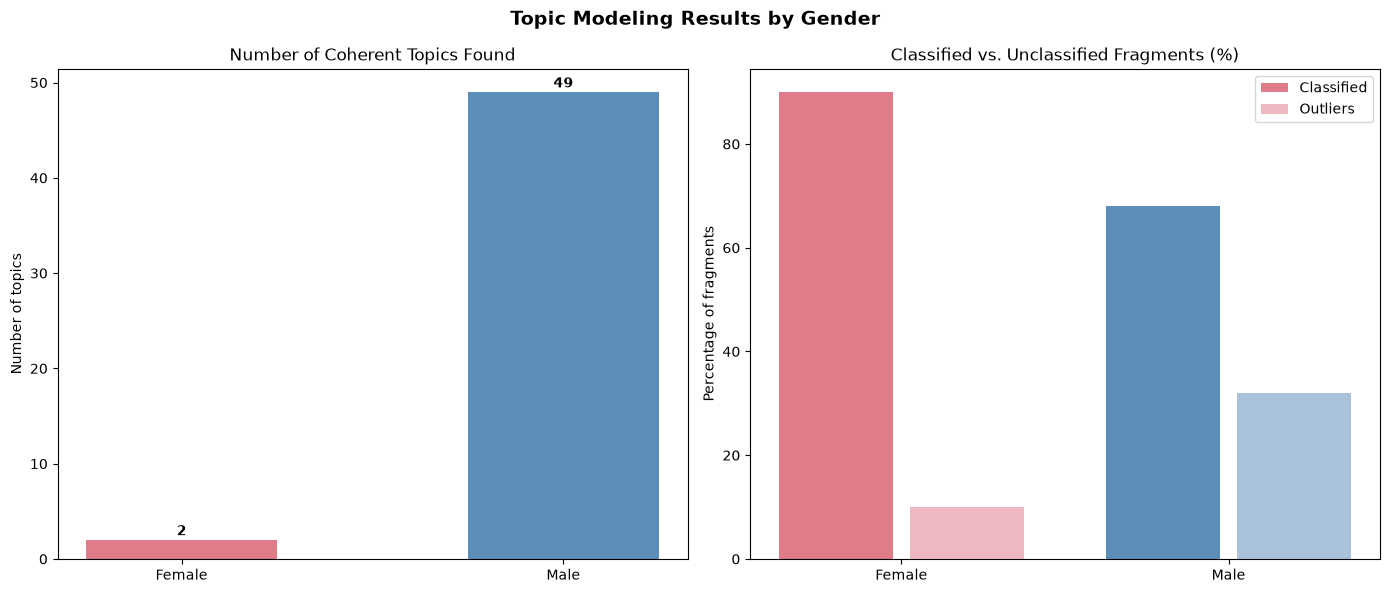

Gráfico guardado como bertopic_comparacion_genero.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Topic Modeling Results by Gender", fontsize=14, fontweight='bold')

# Datos
categorias = ['Coherent\nTopics', 'Unclassified\nFragments', 'Classified\nFragments']
female_vals = [2, 10, 90]    # % aproximados
male_vals = [49, 32, 68]

x = np.arange(len(categorias))
width = 0.35

# Gráfico izquierdo — número de tópicos
axes[0].bar(['Female', 'Male'], [2, 49], color=['#E07B8A', '#5B8DB8'], width=0.5)
axes[0].set_title("Number of Coherent Topics Found")
axes[0].set_ylabel("Number of topics")
for i, v in enumerate([2, 49]):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Gráfico derecho — fragmentos clasificados vs outliers
x = np.arange(2)
axes[1].bar(x - 0.2, [90, 68], width=0.35, label='Classified', color=['#E07B8A', '#5B8DB8'])
axes[1].bar(x + 0.2, [10, 32], width=0.35, label='Outliers', color=['#E07B8A88', '#5B8DB888'])
axes[1].set_title("Classified vs. Unclassified Fragments (%)")
axes[1].set_ylabel("Percentage of fragments")
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Female', 'Male'])
axes[1].legend()

plt.tight_layout()
plt.savefig("bertopic_comparacion_genero.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como bertopic_comparacion_genero.png")